[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Biswajit1999/daily-astro-notebooks/blob/master/gaia/2026-07-30-proper-motion-membership-m67/notebook.ipynb)

# Finding cluster members of M67 using proper motion alone

Proper motion is how fast a star appears to creep across the sky each year, in addition to its distance-driven parallax wobble -- stars that are gravitationally bound together in a cluster share almost the same proper motion, since they're all moving through the galaxy together, while unrelated foreground and background stars have essentially random proper motions. I wanted to see if I could pick out M67 cluster members from field stars using proper motion clustering alone.

In [1]:
from astroquery.gaia import Gaia
import numpy as np
import matplotlib.pyplot as plt

Gaia.ROW_LIMIT = 4000
query = '''
SELECT source_id, pmra, pmdec, parallax, phot_g_mean_mag
FROM gaiadr3.gaia_source
WHERE 1=CONTAINS(POINT('ICRS', ra, dec), CIRCLE('ICRS', 132.825, 11.8, 0.5))
AND pmra IS NOT NULL AND pmdec IS NOT NULL
'''
job = Gaia.launch_job(query)
tab = job.get_results()
print(len(tab), 'stars retrieved in the M67 field')

2000 stars retrieved in the M67 field


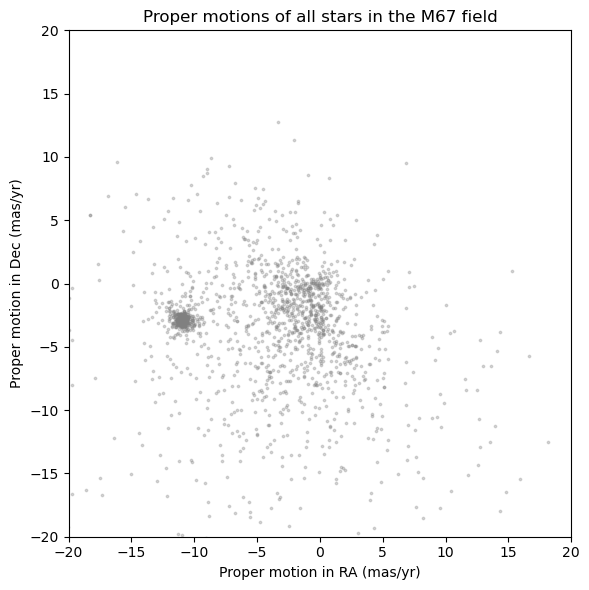

In [2]:
pmra = np.array(tab['pmra'])
pmdec = np.array(tab['pmdec'])

plt.figure(figsize=(6,6))
plt.scatter(pmra, pmdec, s=3, alpha=0.3, color='gray')
plt.xlim(-20, 20); plt.ylim(-20, 20)
plt.xlabel('Proper motion in RA (mas/yr)')
plt.ylabel('Proper motion in Dec (mas/yr)')
plt.title('Proper motions of all stars in the M67 field')
plt.tight_layout()
plt.savefig('m67_pm_all.png', dpi=120)
plt.show()

Candidate cluster members by proper motion: 612 out of 2000


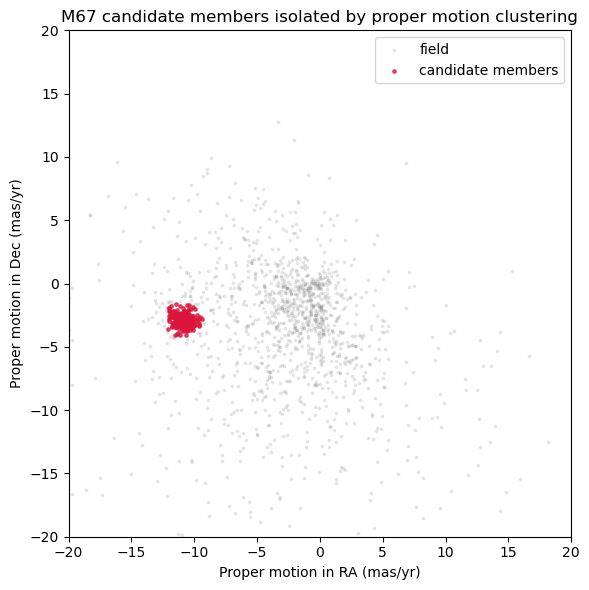

In [3]:
# M67 itself moves at roughly (pmra, pmdec) ~ (-10.9, -2.9) mas/yr
cluster_pm = np.array([-10.9, -2.9])
dist_pm = np.sqrt((pmra-cluster_pm[0])**2 + (pmdec-cluster_pm[1])**2)
members = dist_pm < 1.5
print('Candidate cluster members by proper motion:', members.sum(), 'out of', len(tab))

plt.figure(figsize=(6,6))
plt.scatter(pmra, pmdec, s=3, alpha=0.15, color='gray', label='field')
plt.scatter(pmra[members], pmdec[members], s=6, alpha=0.7, color='crimson', label='candidate members')
plt.xlim(-20, 20); plt.ylim(-20, 20)
plt.xlabel('Proper motion in RA (mas/yr)')
plt.ylabel('Proper motion in Dec (mas/yr)')
plt.legend()
plt.title('M67 candidate members isolated by proper motion clustering')
plt.tight_layout()
plt.savefig('m67_pm_members.png', dpi=120)
plt.show()

A tight clump of stars sharing almost the same proper motion stood out clearly against the much more scattered field population -- exactly the effect I was hoping to see, and it's a nice, intuitive way to find cluster membership without needing radial velocities or spectra at all.

**What I'd look at next:** Add a parallax cut on top of the proper motion cut to clean up the candidate list further, since a few field stars can coincidentally share the cluster's motion.

**Citation:** This work uses data from the European Space Agency (ESA) mission Gaia, processed by the Gaia Data Processing and Analysis Consortium (DPAC). See https://www.cosmos.esa.int/web/gaia/credits.